### Random Forest Baseline

[instruction](https://www.kaggle.com/code/gusthema/house-prices-prediction-using-tfdf/notebook)

In [139]:
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rng = np.random.default_rng(42)

In [140]:
train_file_path = "../../input/house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
print(f"full train dataset shape: {dataset_df.shape}")

full train dataset shape: (1460, 81)


In [141]:
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [142]:
dataset_df = dataset_df.drop('Id', axis=1)

In [143]:
dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [144]:
print(dataset_df['SalePrice'].describe())
print(dataset_df['SalePrice'].skew())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
1.8828757597682129


<Figure size 900x800 with 0 Axes>

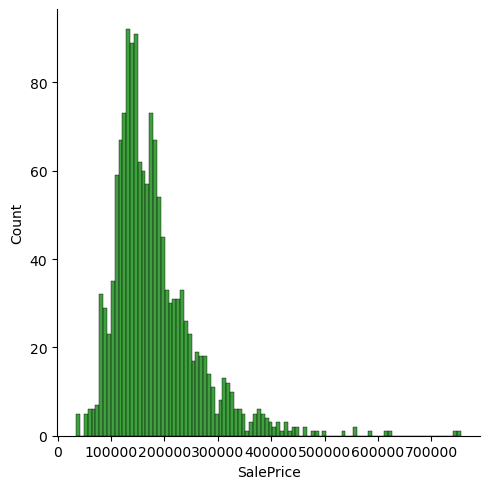

In [145]:
plt.figure(figsize=(9, 8))
sns.displot(dataset_df['SalePrice'], color='g', bins=100)

In [146]:
list(set(dataset_df.dtypes.tolist()))

[dtype('int64'),
 <StringDtype(storage='python', na_value=nan)>,
 dtype('float64')]

In [147]:
feature_df = dataset_df.drop('SalePrice', axis=1)
num_df = feature_df.select_dtypes(include=['float64', 'int64'])
num_df_idx = feature_df.select_dtypes(include=['float64', 'int64']).columns
cat_df_idx = feature_df.select_dtypes(exclude=['float64', 'int64']).columns
print(num_df.shape)
print(num_df_idx, cat_df_idx)

(1460, 36)
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str') Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC',

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

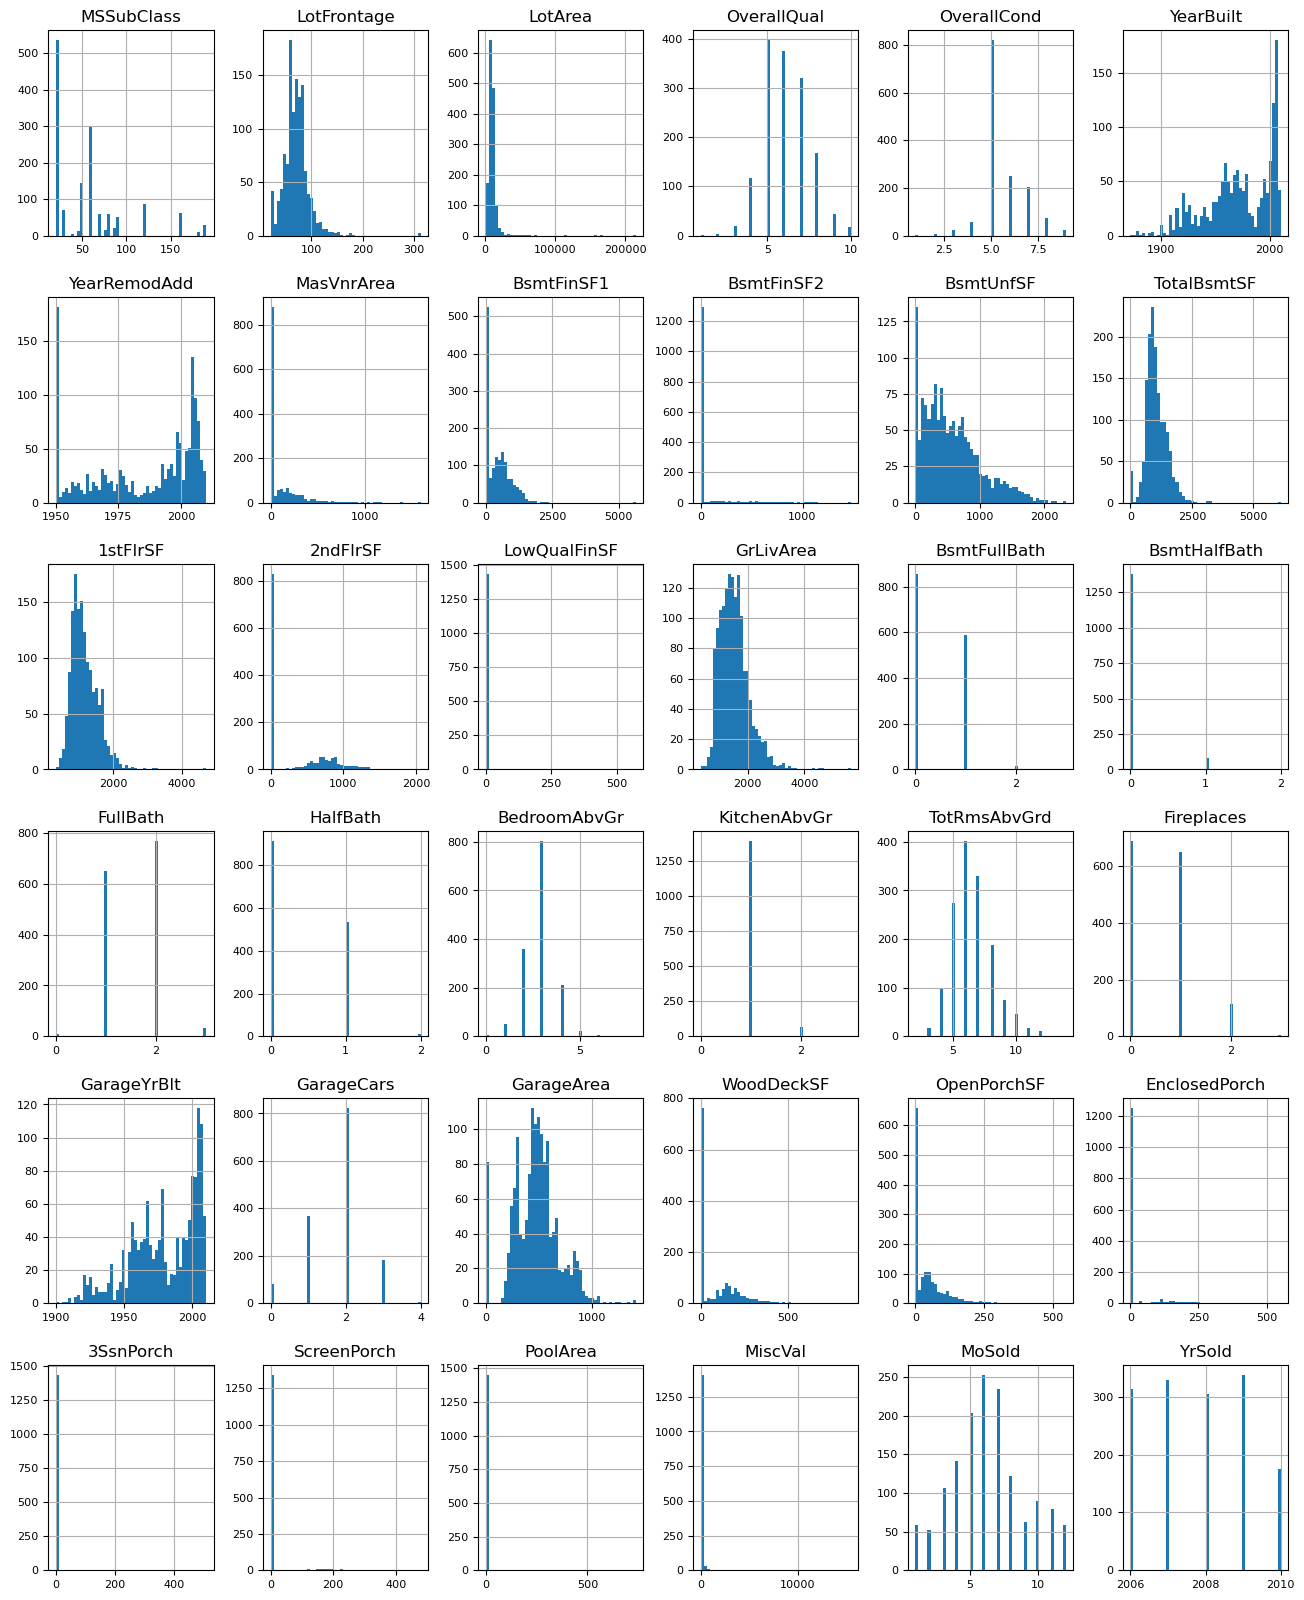

In [148]:
num_df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [149]:
# numerical features
data_mean = dataset_df[num_df_idx].mean()
data_std = dataset_df[num_df_idx].std()
dataset_df[num_df_idx] = (dataset_df[num_df_idx] - data_mean) / data_std
# dataset_df[num_df_idx] = (dataset_df[num_df_idx] - data_mean)
dataset_df[num_df_idx] = dataset_df[num_df_idx].fillna(0)

In [150]:
# catagorical features
dataset_df = pd.get_dummies(dataset_df, dummy_na=True)
print(dataset_df.shape)

(1460, 331)


In [151]:
dataset_df.info()
print(dataset_df.dtypes.value_counts())
# print(train_ds_pd[cat_df_idx].dtypes) 这样是不对的，因为已经经过 one-hot 了，原来的 index 不对了
cat_df_idx = dataset_df.select_dtypes(exclude=['float64']).columns
print(dataset_df[cat_df_idx].dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 331 entries, MSSubClass to SaleCondition_nan
dtypes: bool(294), float64(36), int64(1)
memory usage: 841.3 KB
bool       294
float64     36
int64        1
Name: count, dtype: int64
SalePrice                int64
MSZoning_C (all)          bool
MSZoning_FV               bool
MSZoning_RH               bool
MSZoning_RL               bool
                         ...  
SaleCondition_Alloca      bool
SaleCondition_Family      bool
SaleCondition_Normal      bool
SaleCondition_Partial     bool
SaleCondition_nan         bool
Length: 295, dtype: object


In [152]:
def split_dataset(dataset, vali_ratio=0.25):
    vali_indices = rng.random(len(dataset)) < vali_ratio
    return dataset[~vali_indices], dataset[vali_indices]

train_ds_pd, vali_ds_pd = split_dataset(dataset_df)
print(f"training set size: {len(train_ds_pd)}, validation set size: {len(vali_ds_pd)}")

training set size: 1080, validation set size: 380


In [153]:
n_train = train_ds_pd.shape[0]
n_vali  = vali_ds_pd.shape[0]
# train_ds = torch.tensor(train_ds_pd.astype('float32').to_numpy(), dtype=torch.float32)
# vali_ds = torch.tensor(vali_ds_pd.astype('float32').to_numpy(), dtype=torch.float32)

注意，sklearn 只接受 numpy 和 pandas 的数据，所以不要转成 pytorch

In [154]:
print(train_ds_pd.shape, vali_ds_pd.shape)

(1080, 331) (380, 331)


现在已经写好了 data preprocess 部分了，下面开始正式训练模型

In [155]:
X = train_ds_pd.drop(columns=['SalePrice'])
y = np.log1p(train_ds_pd['SalePrice'])
X_vali = vali_ds_pd.drop(columns=['SalePrice'])
y_vali = np.log1p(vali_ds_pd['SalePrice'])

In [156]:
model = RandomForestRegressor()
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [157]:
y_pred = model.predict(X_vali)
rmse = np.sqrt(mean_squared_error(y_vali, y_pred))
print(rmse)

0.144325189112847


也即现在的均方根误差大概是 0.4，是正常的 RF 跑出来的 Baseline

现在的 logRMSE 是 0.14 左右，作为 baseline